In [ ]:
from pathlib import Path
import pandas as pd
import plotly.express as px

# Find project root (folder containing pyproject.toml)
project_root = None
for d in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    if (d / "pyproject.toml").exists():
        project_root = d
        break

if project_root is None:
    raise RuntimeError("Could not find project root (pyproject.toml)")

csv_path = project_root / "data" / "plot_disp_points.csv"
df = pd.read_csv(csv_path)


fig = px.scatter_3d(
    df,
    x="Qx",
    y="Qy",
    z="phase",
    color="phase",
    opacity=0.35,
    title="3D cloud: arg(sample) for each Q_para",
)
fig.update_traces(marker={"size": 2})




In [ ]:
import sys
from pathlib import Path
import numpy as np
from collections import deque
from joblib import Parallel, delayed
import pandas as pd

# Find project root (folder containing pyproject.toml), then add src/.
project_root = None
for d in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    if (d / "pyproject.toml").exists():
        project_root = d
        src_path = str(d / "src")
        if src_path not in sys.path:
            sys.path.insert(0, src_path)
        break

if project_root is None:
    raise RuntimeError("Could not find project root (pyproject.toml)")

from model.defaults import square_lattice
from band_gap.disp import disp_for_Q
from model import alpha, self_energy
from smatrix import create_self_energy_interpolator_numba



# a horizontal path from (0,0) to (2*(omega_e+\Delta))
n_Q_grid_points = 100
n_k_samples = 500
n_energy_points = 10000
sigma_data = np.load(project_root / "data" / "sigma_grid0f1a.npz")
kx = sigma_data["kx"]
ky = sigma_data["ky"]
sigma_grid = sigma_data["sigma_grid"]
sigma_func_period_numba = create_self_energy_interpolator_numba(
    kx, ky, sigma_grid, lattice=square_lattice
)
collective_lamb_shift = self_energy(
    0, 0, square_lattice.a, square_lattice.d, square_lattice.omega_e, alpha
).real
E = 2 * (square_lattice.omega_e + collective_lamb_shift)
Q_grid_points =  np.linspace(0,E,n_Q_grid_points)
Q_path = deque()


# go through the grid in reverse order but skip the first point (0,0) to avoid duplication
for x in Q_grid_points[:1:-1]:
    Q_path.append((x, 0.0))
for x in Q_grid_points:
    Q_path.append((x, x))


samples_array = Parallel(6, backend="loky")(
        delayed(disp_for_Q)(
            E,
            Q_para,
            n_k_samples,
            n_energy_points,
            sigma_func_period_numba=sigma_func_period_numba,
            lattice=square_lattice,
        )
        for Q_para in Q_path
    )


Qx_all = []
Qy_all = []
phase_all = []

for Q_para, samples in zip(Q_path, samples_array,strict=True):
    if samples.size == 0:
        continue

    phase = np.angle(samples)
    Qx_all.append(np.full(phase.shape, Q_para[0]))
    Qy_all.append(np.full(phase.shape, Q_para[1]))
    phase_all.append(phase)

Qx_all = np.concatenate(Qx_all)
Qy_all = np.concatenate(Qy_all)
phase_all = np.concatenate(phase_all)

finite_mask = np.isfinite(Qx_all) & np.isfinite(Qy_all) & np.isfinite(phase_all)
Qx_all = Qx_all[finite_mask]
Qy_all = Qy_all[finite_mask]
phase_all = phase_all[finite_mask]

df = pd.DataFrame(
    {
        "Qx": Qx_all,
        "Qy": Qy_all,
        "phase": phase_all,
    }
)


Plotted 402,418 phase samples from 162,930,000 rows along 168 Q-path points.


<Axes: title={'center': 'Band gap plot along the first Brillouin-zone Q path'}, xlabel='Q path', ylabel='phase [rad]'>

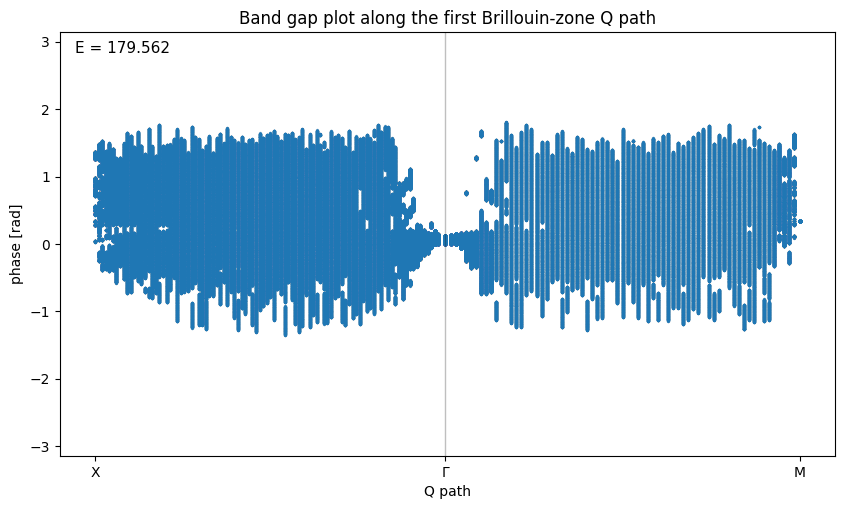

In [ ]:
# Standard band-structure style plot: horizontal axis is cumulative
# distance along the sampled Q path in the first Brillouin zone;
# vertical axis is the sampled phase value at each Q.
q_x_col = "Q_x" if "Q_x" in df.columns else "Qx"
q_y_col = "Q_y" if "Q_y" in df.columns else "Qy"
phase_col = "phase"

# Limit dots per Q point, but choose them across phase bins so genuine
# empty phase regions remain empty and the band-gap structure is preserved.
max_samples_per_q = 2500
phase_bins_per_q = 600

is_new_q = df[[q_x_col, q_y_col]].ne(df[[q_x_col, q_y_col]].shift()).any(axis=1)
q_points = df.loc[is_new_q, [q_x_col, q_y_col]].reset_index(drop=True)
q_xy = q_points[[q_x_col, q_y_col]].to_numpy(dtype=float)

path_distance = np.r_[0.0, np.cumsum(np.linalg.norm(np.diff(q_xy, axis=0), axis=1))]
group_starts = np.flatnonzero(is_new_q.to_numpy())
group_ends = np.r_[group_starts[1:], len(df)]

sample_idx_chunks = []
sample_path_chunks = []
for i, (start, end) in enumerate(zip(group_starts, group_ends, strict=True)):
    n_group = end - start
    if n_group <= max_samples_per_q:
        idx = np.arange(start, end)
    else:
        group_phase = df[phase_col].iloc[start:end].to_numpy()
        finite_pos = np.flatnonzero(np.isfinite(group_phase))

        if finite_pos.size <= max_samples_per_q:
            idx = start + finite_pos
        else:
            finite_phase = group_phase[finite_pos]
            phase_bin = np.floor(
                (finite_phase + np.pi) / (2 * np.pi) * phase_bins_per_q
            ).astype(int)
            phase_bin = np.clip(phase_bin, 0, phase_bins_per_q - 1)

            order = np.argsort(phase_bin, kind="stable")
            sorted_bins = phase_bin[order]
            boundaries = np.r_[
                0, np.flatnonzero(np.diff(sorted_bins)) + 1, len(sorted_bins)
            ]
            n_occupied_bins = len(boundaries) - 1
            samples_per_bin = max(1, max_samples_per_q // n_occupied_bins)

            chosen_pos = []
            for bin_start, bin_end in zip(boundaries[:-1], boundaries[1:], strict=True):
                local_pos = finite_pos[order[bin_start:bin_end]]
                n_take = min(len(local_pos), samples_per_bin)
                chosen_pos.append(
                    local_pos[np.linspace(0, len(local_pos) - 1, n_take, dtype=int)]
                )

            chosen_pos = np.concatenate(chosen_pos)
            if chosen_pos.size > max_samples_per_q:
                keep = np.linspace(0, chosen_pos.size - 1, max_samples_per_q, dtype=int)
                chosen_pos = chosen_pos[keep]

            idx = start + np.sort(chosen_pos)
    sample_idx_chunks.append(idx)
    sample_path_chunks.append(np.full(len(idx), path_distance[i]))

sample_idx = np.concatenate(sample_idx_chunks)
sample_path = np.concatenate(sample_path_chunks)
band_df = df.iloc[sample_idx].copy()
band_df["Q_path"] = sample_path

def high_symmetry_label(qx, qy):
    scale = max(float(np.nanmax(np.abs(q_xy))), 1.0)
    tol = 1e-6 * scale
    if np.hypot(qx, qy) <= tol:
        return "Γ"
    if abs(qy) <= tol:
        return "X"
    if abs(qx) <= tol:
        return "Y"
    if abs(abs(qx) - abs(qy)) <= tol:
        return "M"
    return f"({qx:.3g}, {qy:.3g})"

if len(q_points) > 2:
    dq = np.diff(q_xy, axis=0)
    step = np.linalg.norm(dq, axis=1)
    nonzero = step > 0
    directions = np.zeros_like(dq)
    directions[nonzero] = dq[nonzero] / step[nonzero, None]
    corner_idx = [
        i
        for i in range(1, len(q_points) - 1)
        if np.linalg.norm(directions[i] - directions[i - 1]) > 1e-3
    ]
else:
    corner_idx = []
tick_idx = sorted(set([0, *corner_idx, len(q_points) - 1]))
tick_vals = path_distance[tick_idx]
tick_text = [high_symmetry_label(*q_xy[i]) for i in tick_idx]

ax = band_df.plot.scatter(
    x="Q_path",
    y=phase_col,
    s=2,
    alpha=0.35,
    figsize=(10, 5.5),
    color="#1f77b4",
)

for x in tick_vals[1:-1]:
    ax.axvline(x, color="black", linewidth=1, alpha=0.25)

ax.set_title("Band gap plot along the first Brillouin-zone Q path")
ax.set_xlabel("Q path")
ax.set_ylabel("phase [rad]")
ax.set_ylim(-np.pi, np.pi)
ax.set_xticks(tick_vals)
ax.set_xticklabels(tick_text)
ax.text(
    0.02,
    0.98,
    f"E = {E:.6g}",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=11,
)
ax.grid(False)

print(
    f"Plotted {len(band_df):,} phase samples from {len(df):,} rows "
    f"along {len(q_points):,} Q-path points."
)
ax
